<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/daily_mean_temperature_with_a_Gaussian_Process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.
Path to dataset files: /kaggle/input/daily-climate-time-series-data


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
import os

print("Dataset folder:", path)
print(os.listdir(path))

Dataset folder: /kaggle/input/daily-climate-time-series-data
['DailyDelhiClimateTrain.csv', 'DailyDelhiClimateTest.csv']


In [31]:
import pandas as pd

train_path = os.path.join(path, "DailyDelhiClimateTrain.csv")
test_path = os.path.join(path, "DailyDelhiClimateTest.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

train_df.head()

Training shape: (1462, 5)
Testing shape: (114, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [32]:
print(train_df.columns)

train_df.info()

Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [33]:
train_df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [34]:
# Convert date columns to datetime
train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"] = pd.to_datetime(test_df["date"])

# Sort chronologically
train_df = train_df.sort_values("date").reset_index(drop=True)
test_df = test_df.sort_values("date").reset_index(drop=True)

# REMOVE THE OVERLAPPING TEST DATE
test_df = test_df[test_df["date"] > train_df["date"].max()].reset_index(drop=True)

print("Training period:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTesting period:")
print(test_df["date"].min(), "to", test_df["date"].max())

print("Testing observations:", len(test_df))

Training period:
2013-01-01 00:00:00 to 2017-01-01 00:00:00

Testing period:
2017-01-02 00:00:00 to 2017-04-24 00:00:00
Testing observations: 113


In [35]:
# Summary statistics for mean temperature
train_df["meantemp"].describe()

,meantemp
count,1462.000000
mean,25.495521
std,7.348103
min,6.000000
25%,18.857143
50%,27.714286
75%,31.305804
max,38.714286


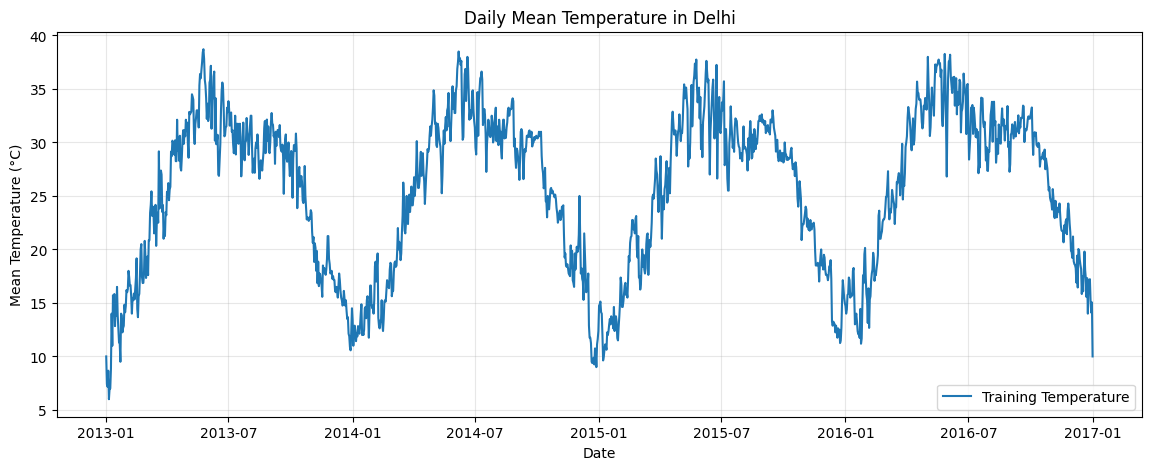

In [36]:
plt.figure(figsize=(14, 5))

plt.plot(
    train_df["date"],
    train_df["meantemp"],
    label="Training Temperature"
)

plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Daily Mean Temperature in Delhi")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [37]:
# Reference date
start_date = train_df["date"].min()

# Convert dates to number of days since the start
train_df["time_idx"] = (train_df["date"] - start_date).dt.days
test_df["time_idx"] = (test_df["date"] - start_date).dt.days

train_df[["date", "time_idx", "meantemp"]].head()

,date,time_idx,meantemp
0,2013-01-01,0,10.000000
1,2013-01-02,1,7.400000
2,2013-01-03,2,7.166667
3,2013-01-04,3,8.666667
4,2013-01-05,4,6.000000


In [38]:
print("Training:")
print(train_df[["date", "time_idx"]].head())
print(train_df[["date", "time_idx"]].tail())

print("\nTesting:")
print(test_df[["date", "time_idx"]].head())
print(test_df[["date", "time_idx"]].tail())

Training:
        date  time_idx
0 2013-01-01         0
1 2013-01-02         1
2 2013-01-03         2
3 2013-01-04         3
4 2013-01-05         4
           date  time_idx
1457 2016-12-28      1457
1458 2016-12-29      1458
1459 2016-12-30      1459
1460 2016-12-31      1460
1461 2017-01-01      1461

Testing:
        date  time_idx
0 2017-01-02      1462
1 2017-01-03      1463
2 2017-01-04      1464
3 2017-01-05      1465
4 2017-01-06      1466
          date  time_idx
108 2017-04-20      1570
109 2017-04-21      1571
110 2017-04-22      1572
111 2017-04-23      1573
112 2017-04-24      1574


In [39]:
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(
    train_df[["time_idx"]]
)

X_test = x_scaler.transform(
    test_df[["time_idx"]]
)

y_train = y_scaler.fit_transform(
    train_df[["meantemp"]]
).ravel()

y_test = y_scaler.transform(
    test_df[["meantemp"]]
).ravel()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1462, 1)
X_test shape: (113, 1)
y_train shape: (1462,)
y_test shape: (113,)


In [40]:
!pip install gpytorch

In [41]:
import torch
import gpytorch

In [42]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)

        # Mean function
        self.mean_module = gpytorch.means.ConstantMean()

        # RBF kernel wrapped in ScaleKernel
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)

        return gpytorch.distributions.MultivariateNormal(
            mean_x,
            covar_x
        )

In [43]:
train_x = torch.tensor(X_train, dtype=torch.float32)
train_y = torch.tensor(y_train, dtype=torch.float32)

test_x = torch.tensor(X_test, dtype=torch.float32)
test_y = torch.tensor(y_test, dtype=torch.float32)

print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

torch.Size([1462, 1])
torch.Size([1462])
torch.Size([113, 1])
torch.Size([113])


In [44]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()

model = ExactGPModel(
    train_x,
    train_y,
    likelihood
)

In [45]:
model.train()
likelihood.train()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.1
)

mll = gpytorch.mlls.ExactMarginalLogLikelihood(
    likelihood,
    model
)

training_iterations = 100

for i in range(training_iterations):

    optimizer.zero_grad()

    output = model(train_x)

    loss = -mll(output, train_y)

    loss.backward()

    optimizer.step()

    if (i + 1) % 10 == 0:
        print(
            f"Iteration {i+1}/{training_iterations} - "
            f"Loss: {loss.item():.3f} - "
            f"Lengthscale: "
            f"{model.covar_module.base_kernel.lengthscale.item():.3f} - "
            f"Noise: {likelihood.noise.item():.3f}"
        )

Iteration 10/100 - Loss: 0.802 - Lengthscale: 0.328 - Noise: 0.513
Iteration 20/100 - Loss: 0.402 - Lengthscale: 0.183 - Noise: 0.213
Iteration 30/100 - Loss: 0.143 - Lengthscale: 0.116 - Noise: 0.081
Iteration 40/100 - Loss: 0.142 - Lengthscale: 0.054 - Noise: 0.043
Iteration 50/100 - Loss: 0.086 - Lengthscale: 0.017 - Noise: 0.036
Iteration 60/100 - Loss: 0.234 - Lengthscale: 0.007 - Noise: 0.026
Iteration 70/100 - Loss: 0.210 - Lengthscale: 0.007 - Noise: 0.016
Iteration 80/100 - Loss: 0.217 - Lengthscale: 0.006 - Noise: 0.014
Iteration 90/100 - Loss: 0.165 - Lengthscale: 0.006 - Noise: 0.016
Iteration 100/100 - Loss: 0.120 - Lengthscale: 0.008 - Noise: 0.022


# Forecasting and Evaluation

In [46]:
# Put model and likelihood in evaluation mode
model.eval()
likelihood.eval()

# Generate predictions
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = likelihood(model(test_x))

    pred_mean_scaled = predictions.mean.cpu().numpy()

    lower_scaled, upper_scaled = predictions.confidence_region()

    lower_scaled = lower_scaled.cpu().numpy()
    upper_scaled = upper_scaled.cpu().numpy()

In [47]:
# Convert predictions back to degrees Celsius
pred_mean = y_scaler.inverse_transform(
    pred_mean_scaled.reshape(-1, 1)
).ravel()

lower = y_scaler.inverse_transform(
    lower_scaled.reshape(-1, 1)
).ravel()

upper = y_scaler.inverse_transform(
    upper_scaled.reshape(-1, 1)
).ravel()

actual = test_df["meantemp"].values

In [48]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(actual, pred_mean)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f} °C")

MSE: 50.892
RMSE: 7.134 °C


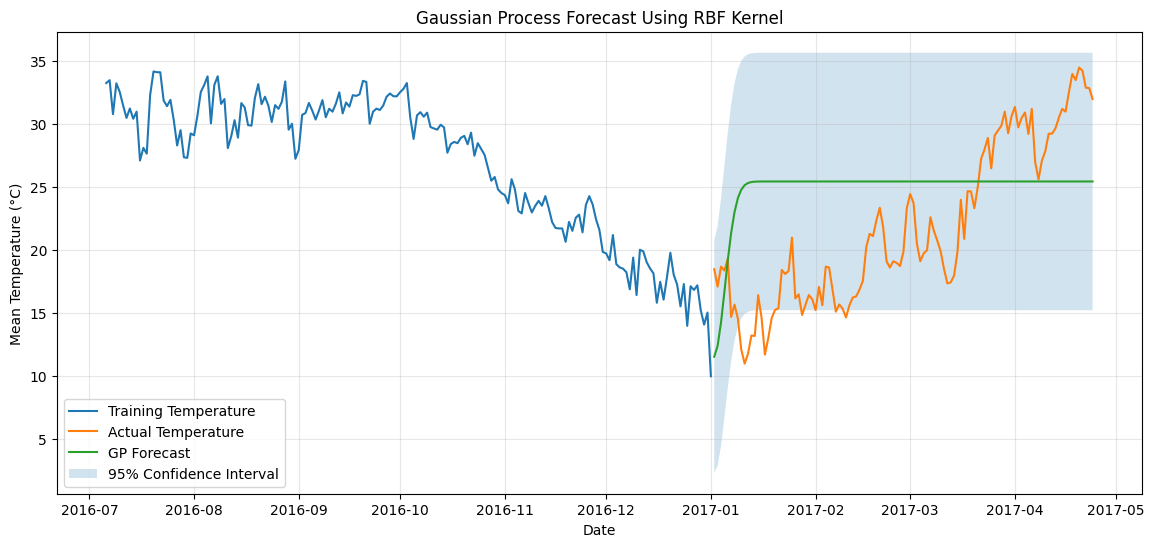

In [49]:
plt.figure(figsize=(14, 6))

# Recent training history
recent_train = train_df.tail(180)

plt.plot(
    recent_train["date"],
    recent_train["meantemp"],
    label="Training Temperature"
)

# Actual test temperatures
plt.plot(
    test_df["date"],
    actual,
    label="Actual Temperature"
)

# GP prediction
plt.plot(
    test_df["date"],
    pred_mean,
    label="GP Forecast"
)

# 95% confidence interval
plt.fill_between(
    test_df["date"],
    lower,
    upper,
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Gaussian Process Forecast Using RBF Kernel")
plt.legend()
plt.grid(alpha=0.3)

plt.show()